# Plotting Regions on NGC 253: Disk

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import os
import shutil
from astropy.io import fits # importing fits 
from astropy.utils.data import download_file # simple method of downloading FITS file 
from astropy.visualization import astropy_mpl_style # resource for organized plots
from astropy.visualization import ZScaleInterval, MinMaxInterval, AsinhStretch, LogStretch, ImageNormalize # quality image display/visualization
from astropy.wcs import WCS #coordinate conversion
from regions import Regions # import astropy region class

In [2]:
class DisplayData: 
    """" A class to open FITS file, display image data, 
         and plot a DS9.reg file onto the image data. """ 
    def __init__(self, filepath):
        """ Initialize through opening the data.""" 
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul: # opening file
            data = None
            header = None
            for hdu in hdul: #loops through each extension (HDU) in the list of HDUs to check if data has dimensions (thanks rav!)
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
       # hdu = fits.open(filepath)[1] #okay index 1 isn't always gong to work. you need to write an if statement to test 0


    def display_header(self, filepath):
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")

    def display_image(self, filepath, norm, vmin, vmax):
        self.filepath = filepath 
        self.norm = norm
        self.vmin = vmin
        self.vmax = vmax
         #brightness control
        #hdu = fits.open(filepath)[1]
        #data = hdu.data
        #header = hdu.header 
        from astropy.io import fits
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    if len(np.shape(data)) > 2:
                        data = data[0]
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")



        plt.figure(figsize=(8, 8))
        plt.imshow(data, cmap="gray", origin="lower", norm=self.norm, vmin=self.vmin, vmax=self.vmax) #figure out a way to add normalization parameter into this function
        plt.colorbar(label="Intensity", fraction=0.0146, aspect=20)
        plt.show()

    
    def plot_region(self, filepath, regionfile, norm, vmin, vmax):
        self.filepath = filepath
        self.regionfile = regionfile # DS9 region
        self.norm = norm 
        self.vmin = vmin
        self.vmax= vmax
        
        from astropy.io import fits 
        from astropy.wcs import WCS
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    if len(np.shape(data)) > 2:
                        data = data[0]
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
       
            
        wcs = WCS(header, naxis=2) #see https://astronomy.stackexchange.com/questions/51673/how-to-slice-wcs-in-a-fits-file
        region = Regions.read(regionfile)[0].to_pixel(wcs) # access region file via parsing & converting data from wcs to pixel
        fig, ax = plt.subplots() 
        ax.imshow(data, cmap='gray', origin='lower', norm=self.norm, vmin=self.vmin, vmax=self.vmax)
        region.plot(ax=ax, color='red', lw=2.0)
        

## CO: ACA

Found data in extension: PRIMARY
Found data in extension: PRIMARY


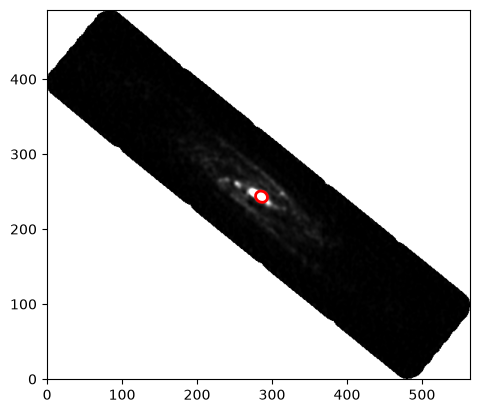

In [7]:
co_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\ngc0253_7m+tp_co21_mom0.fits"
co_data = DisplayData(co_file)
co_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_co_regionfile_aca.reg"
co_data.plot_region(co_file, co_center_regionfile, norm='linear', vmin=0.00003, vmax=300)

## H-alpha - MUSE

Found data in extension: HA6562_FLUX
Found data in extension: HA6562_FLUX


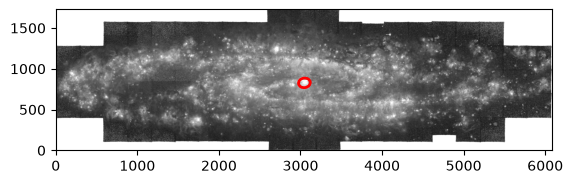

In [8]:
ha_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\NGC0253_Ha.fits"
ha_data = DisplayData(ha_file)
ha_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_ha_regionfile_muse.reg"
ha_data.plot_region(ha_file, ha_center_regionfile, norm = 'log', vmin=30, vmax=30000)

## IRAC1: Spitzer

Found data in extension: PRIMARY
Found data in extension: PRIMARY


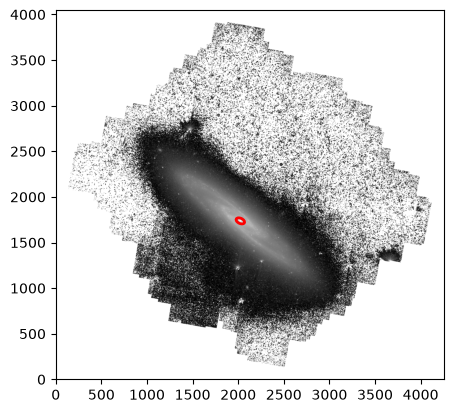

In [9]:
irac1_file= r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ngc0253_lvl_release_irac1_gauss3.fits"
irac1_data = DisplayData(irac1_file)
irac1_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_irac1_regionfile_spitzer.reg"
irac1_data.plot_region(irac1_file, irac1_center_regionfile, norm='log', vmin=0.005, vmax=255)

## IRAC4: Spitzer

Found data in extension: PRIMARY
Found data in extension: PRIMARY


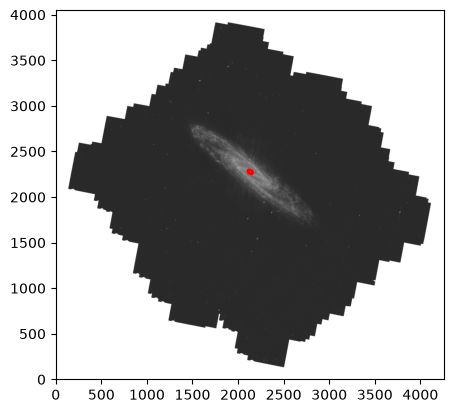

In [11]:
irac4_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\ngc0253_irac4_gauss4p0.fits"
irac4_data = DisplayData(irac4_file)
irac4_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_irac4_regionfile_spitzer.reg"
irac4_data.plot_region(irac4_file, irac4_center_regionfile, 'asinh', None, None)

## R-band: WFI

Found data in extension: PRIMARY
Found data in extension: PRIMARY


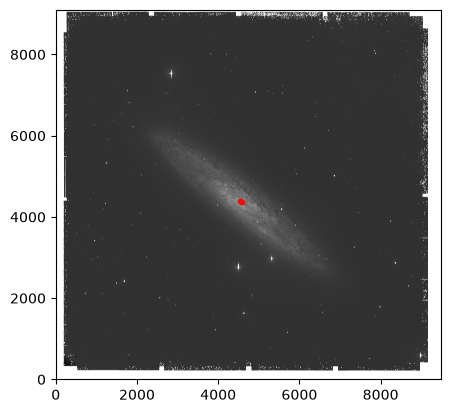

In [12]:
rband_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\NGC0253_Rc_flux_wcomb.fits"
rband_data = DisplayData(rband_file)
rband_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_rband_regionfile_wfi.reg"
rband_data.plot_region(rband_file, rband_center_regionfile, 'asinh', None, None)

## UVIS: HST

In [ ]:
uvis_file= r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/NGC0253V2_Ha.fits"
uvis_data = DisplayData(uvis_file)
uvis_disk_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/disk_uvis_regionfile_hst.reg"
uvis_data.plot_region(uvis_file, uvis_disk_regionfile, norm=None, vmin=0, vmax=30)

## V-band: MUSE

In [ ]:
vband_file= r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\NGC0253_V.fits"
vband_data = DisplayData(vband_file)
vband_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_vband_regionfile_muse.reg"
vband_data.plot_region(vband_file, vband_center_regionfile, norm='log', vmin=30, vmax=30000)

## W1: WISE

In [ ]:
w1_file= r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\ngc0253_w1_bgsub.fits"
w1_data = DisplayData(w1_file)
w1_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_w1_regionfile_wise1.reg"
w1_data.plot_region(w1_file, w1_center_regionfile, norm='log', vmin=0.005, vmax=255)